# Prospective Donor Persona Discovery
## Engineering notebook
> **Temporary A/B experiment notebook (`delete`):** tests four explicit within-block down-weights against the unchanged shortlist systems. This does not adopt, name, or freeze a persona architecture.

This notebook implements the agreed analysis design for the September 2024 DonorsChoose donor-segmentation survey.

### Governing decisions

- Discover personas using **attention-pass panel prospects only**.
- Hold current/past DonorsChoose donors out of model fitting, then assign them to fixed prospect personas.
- Use a curated, question-balanced mixed-type distance and k-medoids.
- Treat each select-all question as one Jaccard distance so shared non-selections do not create false similarity.
- Keep demographics, media, lifestyle, source/history, legacy labels, and organization write-ins out of cluster formation.
- Show only the approved descriptive evidence and a minimal, cut-and-dry legacy-model validation.
- Name personas only after stability and business-actionability review.

### Notebook outputs

1. Fixed descriptive evidence tables.
2. Three-run PCA/KMeans forensic validation.
3. Governed prospect modeling schema.
4. Weighted mixed-type distance and k-medoids candidates for k=3 through k=6.
5. Simple resampling and sensitivity checks.
6. Post-fit current-donor assignment and natural-fit ranking.
7. Persona profiling scaffolds.
8. Separate organization write-in extraction, normalization, and optional OpenAI enrichment.
9. Reproducibility manifest and export files.

The notebook is intentionally explicit rather than framework-heavy. It is designed to be handed to another engineer and reviewed by marketing and product partners.

## 0. Setup and run contract

The notebook uses only common scientific Python packages for the primary analysis. The optional organization-enrichment section uses the OpenAI Python SDK only when explicitly enabled.

Set `DONOR_PERSONA_DATA_DIR` if the files are not in the notebook directory or `/mnt/data`. All generated files go to `persona_outputs` by default.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import re
import sys
import warnings
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display, Markdown
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

RAW_FILENAME = 'Donor Segmentation Survey - Clean Raw Data (PII Removed) - DonorsChoose - September 2024.xlsx - Export.csv'
PCA_FILENAME = 'DonorsChoose Cluster Analysis Details.xlsx - PCA Factor Loadings.csv'
SURVEY_FILENAME = 'FINAL_Donor Segmentation Survey - Final for Fielding.docx.pdf'
HANDOFF_FILENAME = 'Donor_Persona_Analysis_Engineering_Handoff.docx'

candidate_dirs = [
    Path(os.getenv('DONOR_PERSONA_DATA_DIR', '.')).expanduser().resolve(),
    Path('/mnt/data'),
]
DATA_DIR = next((p for p in candidate_dirs if (p / RAW_FILENAME).exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        f'Could not find {RAW_FILENAME!r}. Set DONOR_PERSONA_DATA_DIR to the folder containing the source files.'
    )

OUTPUT_DIR = Path(os.getenv('DONOR_PERSONA_OUTPUT_DIR', DATA_DIR / 'persona_outputs')).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = DATA_DIR / RAW_FILENAME
PCA_PATH = DATA_DIR / PCA_FILENAME
SURVEY_PATH = DATA_DIR / SURVEY_FILENAME
HANDOFF_PATH = DATA_DIR / HANDOFF_FILENAME

SEED = 17
K_VALUES = (3, 4, 5, 6)
KMEDOIDS_N_INIT = 8
KMEDOIDS_MAX_ITER = 50
STABILITY_RUNS = 20          # Use 100 for the final production sign-off.
STABILITY_FRACTION = 0.80
WORKING_K_OVERRIDE = None    # Set to 3, 4, 5, or 6 after stakeholder review.
RUN_LLM_ENRICHMENT = False   # Requires OPENAI_API_KEY and explicit review of cost/data governance.
OPENAI_MODEL = os.getenv('OPENAI_MODEL', 'gpt-5-mini')

BLOCK_WEIGHTS_BASELINE = {
    'giving_commitment': 1.0,
    'giving_job_impact': 1.0,
    'trust_research_friction': 1.0,
    'trigger_channel': 1.0,
    'education_receptivity': 1.0,
}

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Primary seed: {SEED}')

Data directory: /Users/matt.fritz/Downloads
Output directory: /Users/matt.fritz/Downloads/persona_outputs
Primary seed: 17


## 1. Load, fingerprint, and assert the source data

These assertions are intentional. They make schema drift or a different survey export fail loudly rather than silently changing the analysis.

In [2]:
def sha256_file(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

raw = pd.read_csv(RAW_PATH, low_memory=False)
pca_loadings_raw = pd.read_csv(PCA_PATH)

QC_COL = 'For quality control purposes, please select "Somewhat disagree" - To what extent do you agree with each of the following statements about charitable donations?'
ID_COL = 'responseidkey'
SOURCE_COL = 'Source'
HISTORY_COL = 'DonorsChoose Donation History'
LEGACY_CLUSTER_COL = 'Four Cluster Solution'

required_columns = {ID_COL, SOURCE_COL, HISTORY_COL, LEGACY_CLUSTER_COL, QC_COL}
missing_required = required_columns.difference(raw.columns)
assert not missing_required, f'Missing required columns: {sorted(missing_required)}'
assert raw.shape == (1438, 884), f'Unexpected raw shape: {raw.shape}'
assert raw[ID_COL].is_unique, 'Respondent key is not unique.'

attention_pass = raw[QC_COL].eq('Somewhat disagree')
retained = raw.loc[attention_pass].copy()
prospect_mask_retained = retained[SOURCE_COL].eq('Panel')
donor_mask_retained = retained[SOURCE_COL].eq('List')

assert attention_pass.sum() == 1245
assert (~attention_pass).sum() == 193
assert prospect_mask_retained.sum() == 1120
assert donor_mask_retained.sum() == 125
assert raw[SOURCE_COL].eq('List').sum() == 141
assert raw[HISTORY_COL].eq('Past donor (List)').equals(raw[SOURCE_COL].eq('List'))
assert retained[HISTORY_COL].eq('Past donor (List)').equals(retained[SOURCE_COL].eq('List'))
assert ((raw[SOURCE_COL].eq('List')) & raw[LEGACY_CLUSTER_COL].eq('Academic Advocates')).sum() == 135
assert ((retained[SOURCE_COL].eq('List')) & retained[LEGACY_CLUSTER_COL].eq('Academic Advocates')).sum() == 119

input_manifest = pd.DataFrame([
    {'artifact': 'raw survey export', 'path': str(RAW_PATH), 'sha256': sha256_file(RAW_PATH), 'bytes': RAW_PATH.stat().st_size},
    {'artifact': 'PCA factor loadings', 'path': str(PCA_PATH), 'sha256': sha256_file(PCA_PATH), 'bytes': PCA_PATH.stat().st_size},
    {'artifact': 'survey instrument', 'path': str(SURVEY_PATH), 'sha256': sha256_file(SURVEY_PATH) if SURVEY_PATH.exists() else None, 'bytes': SURVEY_PATH.stat().st_size if SURVEY_PATH.exists() else None},
    {'artifact': 'analysis handoff', 'path': str(HANDOFF_PATH), 'sha256': sha256_file(HANDOFF_PATH) if HANDOFF_PATH.exists() else None, 'bytes': HANDOFF_PATH.stat().st_size if HANDOFF_PATH.exists() else None},
])
display(input_manifest)

,artifact,path,sha256,bytes
0,raw survey export,/Users/matt.fritz/Downloads/Donor Segmentation Survey - Clean Raw Data (PII Removed) - DonorsChoose - September 2024...,78bd8f48da9211bbc999a7fe6217f1043c5e1a400e6806b4e44b9b1416bf3ea0,8298660
1,PCA factor loadings,/Users/matt.fritz/Downloads/DonorsChoose Cluster Analysis Details.xlsx - PCA Factor Loadings.csv,22b3112a1da4bdeb1b85681cab024f270ed64e51b8d4dc0bfa481b2b89258ea4,2024
2,survey instrument,/Users/matt.fritz/Downloads/FINAL_Donor Segmentation Survey - Final for Fielding.docx.pdf,0aaf402f0f86863407798631c4576d0b9a4bb7921987dd9604da7b9f4bc7ffa5,889306
3,analysis handoff,/Users/matt.fritz/Downloads/Donor_Persona_Analysis_Engineering_Handoff.docx,12ae1b750be6ba75471d5bb1f67b463aab9ff38dc25f73fa48aead132b1f9ae1,184112


## 2. Survey-column helpers and fixed encodings

The raw export contains both original answers and many derived response-option/Top-2 columns. The helpers below only construct fields from original answers and genuine select-all options.

In [3]:
Q_IMPORTANCE = 'How would you rate the importance of each of the following attributes when selecting an organization/cause to make a charitable donation to?'
Q_MOTIVATIONS = 'Which of the following motivates you to make a charitable donation? Select all that apply.'
Q_IMPACT_SCALE = 'Which of the following best describes the scale at which you prefer your charitable donations to make an impact?'
Q_CURRENT_CAUSES = 'Which of the following causes/organizations do you typically make charitable donations to? Select all that apply.'
Q_OPENNESS = 'You indicated that you do not currently make charitable donations to the following causes/organizations. How open are you to making a charitable donation to these causes in the future?'
Q_EDU_FORMATS = 'Which of the following types of education-related charitable donations would you be most likely to make? Select up to two (2).'
Q_DISCOVERY = 'Which, if any, of these sources have you used to discover new organizations or causes to donate to? Select all that apply.'
Q_RESEARCH_SOURCES = 'What sources of information do you use when researching organizations/causes to make a charitable donation? Select all that apply.'
Q_RESEARCH_INFO = 'What kinds of information did you look for when researching organizations/causes to make a charitable donation? Select all that apply.'
Q_CHALLENGES = 'Which of the following challenges do you encounter when making a charitable donation? Select all that apply.'
Q_MESSAGING = 'How influential is the following messaging when deciding to make a charitable donation?'
Q_AD_RESPONSE = 'Have you ever made a charitable donation in response to any of the following forms of advertising/messaging? Select your top three (3).'
Q_CHARITY_ATTITUDES = 'To what extent do you agree with each of the following statements about charitable donations?'

FREQUENCY_COL = 'How often do you make charitable donations?'
AMOUNT_COL = 'What is the average donation amount you typically donate to charitable organizations/causes? Your best guess is fine.'
ORG_COUNT_COL = 'How many charitable organizations, on average, do you donate to in a given year?'
DONATION_COUNT_COL = 'On average, how many times per year do you make an individual charitable donation?'
DECISION_COL = 'Which of the following best describes you at the point before you make a charitable donation to an organization?'

IMPORTANT_MAP = {
    'Not at all important': 1,
    'Slightly important': 2,
    'Moderately important': 3,
    'Very important': 4,
    'Extremely important': 5,
}
INFLUENTIAL_MAP = {
    'Not at all influential': 1,
    'Slightly influential': 2,
    'Moderately influential': 3,
    'Very influential': 4,
    'Extremely influential': 5,
}
AGREE_MAP = {
    'Strongly disagree': 1,
    'Somewhat disagree': 2,
    'Neither agree nor disagree': 3,
    'Somewhat agree': 4,
    'Strongly agree': 5,
}
OPEN_MAP = {
    'Not at all open': 1,
    'Slightly open': 2,
    'Moderately open': 3,
    'Very open': 4,
    'Extremely open': 5,
}
FREQUENCY_MAP = {
    'Once a year': 1,
    'Once every 4 to 6 months': 2,
    'Once every 2 to 3 months': 3,
    'Once a month': 4,
    'More often than once a month': 5,
}
AMOUNT_MAP = {
    'Less than $10': 1,
    '$10-$19': 2,
    '$20-$49': 3,
    '$50-$99': 4,
    '$100 - $499': 5,
    '$500 - $999': 6,
    '$1,000 - $9,999': 7,
    '$10,000 or more': 8,
}

DERIVED_SUFFIXES = {
    *IMPORTANT_MAP,
    *INFLUENTIAL_MAP,
    *AGREE_MAP,
    *OPEN_MAP,
    'Top 2',
}


def likert_col(item: str, question: str) -> str:
    col = f'{item} - {question}'
    if col not in raw.columns:
        raise KeyError(col)
    return col


def option_col(question: str, option: str) -> str:
    col = f'{question} - {option}'
    if col not in raw.columns:
        raise KeyError(col)
    return col


def selected(frame: pd.DataFrame, question: str, option: str) -> pd.Series:
    return frame[option_col(question, option)].notna()


def decode_single_choice(frame: pd.DataFrame, question: str, options: Sequence[str]) -> pd.Series:
    cols = [option_col(question, option) for option in options]
    indicator = frame[cols].notna().astype(int)
    row_total = indicator.sum(axis=1)
    if not row_total.eq(1).all():
        bad = row_total[~row_total.eq(1)]
        raise ValueError(f'{question}: expected exactly one selected option; bad rows={len(bad)}')
    values = np.asarray(options, dtype=object)[indicator.to_numpy().argmax(axis=1)]
    return pd.Series(values, index=frame.index, name=question)


def pct(series: pd.Series) -> float:
    return float(series.mean())


def pct_str(value: float) -> str:
    return f'{value:.1%}'


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=True)
    return path

# Workstream A - Fixed descriptive evidence

Only the approved findings are produced here. There is no generic correlation scan, generic top-N segment profiler, or automatic story generation.

## A1. File structure and quality exclusions

In [4]:
derived_columns = []
for col in raw.columns:
    if ' - ' not in col:
        continue
    base, suffix = col.rsplit(' - ', 1)
    if base in raw.columns and suffix in DERIVED_SUFFIXES:
        derived_columns.append(col)

qc_derived = [c for c in derived_columns if c.startswith('For quality control purposes')]
modeling_duplicate_columns = [c for c in derived_columns if c not in qc_derived]

all_blank_columns = [c for c in raw.columns if raw[c].isna().all()]
constant_nonblank_columns = [c for c in raw.columns if raw[c].nunique(dropna=True) == 1 and c not in all_blank_columns]
genuine_sparse_options = [
    c for c in raw.columns
    if c not in derived_columns
    and 'Text_' not in c
    and raw[c].nunique(dropna=True) == 1
    and raw[c].notna().any()
    and raw[c].isna().any()
]
original_multi_value_columns = [c for c in raw.columns if raw[c].nunique(dropna=True) > 1]

structure_audit = pd.DataFrame([
    ('Respondents', raw.shape[0]),
    ('Exported fields', raw.shape[1]),
    ('Redundant five-point response-option/Top-2 derivatives excluding QC', len(modeling_duplicate_columns)),
    ('Original five-point items represented by those derivatives', len({c.rsplit(' - ', 1)[0] for c in modeling_duplicate_columns})),
    ('Genuine sparse select-all option fields', len(genuine_sparse_options)),
    ('Original fields with multiple observed values', len(original_multi_value_columns)),
    ('Fully blank fields', len(all_blank_columns)),
    ('One-value nonblank fields', len(constant_nonblank_columns)),
], columns=['Measure', 'Value']).set_index('Measure')

assert len(modeling_duplicate_columns) == 450
assert len({c.rsplit(' - ', 1)[0] for c in modeling_duplicate_columns}) == 75
assert len(genuine_sparse_options) == 299
assert len(original_multi_value_columns) == 117
assert len(all_blank_columns) == 15

display(structure_audit)
save_table(structure_audit, 'A1_structure_audit.csv')

population_table = pd.DataFrame([
    ('Full qualified file', len(raw)),
    ('Attention-check pass', len(retained)),
    ('Attention-check fail - excluded', int((~attention_pass).sum())),
    ('Retained panel prospects - modeling population', int(prospect_mask_retained.sum())),
    ('Retained list/past donors - post-fit cohort', int(donor_mask_retained.sum())),
], columns=['Population', 'n']).set_index('Population')
display(population_table)
save_table(population_table, 'A2_population_counts.csv')

,Value
Measure,
Respondents,1438
Exported fields,884
Redundant five-point response-option/Top-2 derivatives excluding QC,450
Original five-point items represented by those derivatives,75
Genuine sparse select-all option fields,299
Original fields with multiple observed values,117
Fully blank fields,15
One-value nonblank fields,752


,n
Population,
Full qualified file,1438
Attention-check pass,1245
Attention-check fail - excluded,193
Retained panel prospects - modeling population,1120
Retained list/past donors - post-fit cohort,125


PosixPath('/Users/matt.fritz/Downloads/persona_outputs/A2_population_counts.csv')

## A2. Source/history equivalence and the legacy cluster confound

In [5]:
source_history = pd.crosstab(raw[SOURCE_COL], raw[HISTORY_COL], margins=True)
source_by_legacy = pd.crosstab(raw[LEGACY_CLUSTER_COL], raw[SOURCE_COL], margins=True)
source_by_legacy['List share'] = source_by_legacy.get('List', 0) / source_by_legacy['All']

display(source_history)
display(source_by_legacy)
save_table(source_history, 'A3_source_history_equivalence.csv')
save_table(source_by_legacy, 'A4_source_by_legacy_cluster.csv')

legacy_donor_evidence = pd.DataFrame({
    'Measure': [
        'Past donors labeled Academic Advocates',
        'Academic Advocates who are past donors',
        'Attention-pass past donors labeled Academic Advocates',
    ],
    'Value': [
        ((raw[SOURCE_COL].eq('List')) & raw[LEGACY_CLUSTER_COL].eq('Academic Advocates')).sum() / raw[SOURCE_COL].eq('List').sum(),
        ((raw[SOURCE_COL].eq('List')) & raw[LEGACY_CLUSTER_COL].eq('Academic Advocates')).sum() / raw[LEGACY_CLUSTER_COL].eq('Academic Advocates').sum(),
        ((retained[SOURCE_COL].eq('List')) & retained[LEGACY_CLUSTER_COL].eq('Academic Advocates')).sum() / retained[SOURCE_COL].eq('List').sum(),
    ]
}).set_index('Measure')
legacy_donor_evidence['Display'] = legacy_donor_evidence['Value'].map(pct_str)
display(legacy_donor_evidence[['Display']])
save_table(legacy_donor_evidence, 'A5_legacy_donor_confound.csv')

DonorsChoose Donation History,Future donor (panel),Past donor (List),All
Source,,,
List,0,141,141
Panel,1297,0,1297
All,1297,141,1438


Source,List,Panel,All,List share
Four Cluster Solution,,,,
Academic Advocates,135,50,185,0.730
Emotion Driven Crisis Responders,2,296,298,0.007
Pragmatic Community Builders,1,373,374,0.003
Traditional Casual Donors,3,578,581,0.005
All,141,1297,1438,0.098


,Display
Measure,
Past donors labeled Academic Advocates,95.7%
Academic Advocates who are past donors,73.0%
Attention-pass past donors labeled Academic Advocates,95.2%


PosixPath('/Users/matt.fritz/Downloads/persona_outputs/A5_legacy_donor_confound.csv')

## A3. Legacy response-intensity ordering

This is a diagnostic, not a claim that response intensity fully explains the old solution. It tests whether the legacy clusters are broadly ordered by how highly respondents use five-point scales.

,n,mean_likert
legacy_cluster,,
Traditional Casual Donors,581,2.969
Academic Advocates,185,3.190
Emotion Driven Crisis Responders,298,3.533
Pragmatic Community Builders,374,3.798


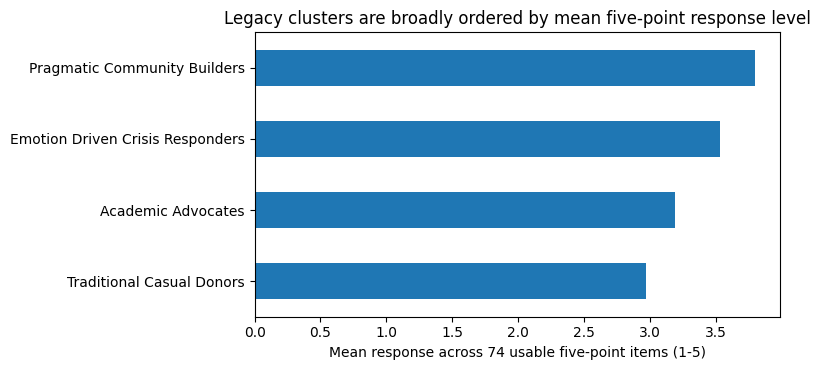

In [6]:
def original_five_point_columns(frame: pd.DataFrame) -> list[tuple[str, Mapping[str, int]]]:
    mappings = [IMPORTANT_MAP, INFLUENTIAL_MAP, AGREE_MAP, OPEN_MAP]
    result = []
    for col in frame.columns:
        if col == QC_COL:
            continue
        values = set(frame[col].dropna().unique())
        for mapping in mappings:
            if values and values.issubset(mapping.keys()) and frame[col].nunique(dropna=True) > 1:
                result.append((col, mapping))
                break
    return result

five_point_fields = original_five_point_columns(raw)
assert len(five_point_fields) == 74

likert_numeric = pd.DataFrame(
    {col: raw[col].map(mapping) for col, mapping in five_point_fields},
    index=raw.index,
)
raw_response_intensity = likert_numeric.mean(axis=1)
response_intensity_table = (
    pd.DataFrame({'legacy_cluster': raw[LEGACY_CLUSTER_COL], 'mean_likert': raw_response_intensity})
    .groupby('legacy_cluster')
    .agg(n=('mean_likert', 'size'), mean_likert=('mean_likert', 'mean'))
    .sort_values('mean_likert')
)
display(response_intensity_table)
save_table(response_intensity_table, 'A6_legacy_response_intensity.csv')

ax = response_intensity_table['mean_likert'].plot(kind='barh', figsize=(8, 3.8), title='Legacy clusters are broadly ordered by mean five-point response level')
ax.set_xlabel('Mean response across 74 usable five-point items (1-5)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## A4. Qualified-sample limitations

The survey intentionally screened for recent charitable donors with household income of at least $60,000. The table below describes the full qualified file, matching the study-design limitation rather than the prospect-only modeling population.

In [7]:
AGE_COL = 'How old are you?'
EMPLOYMENT_COL = 'Which of the following best describes your current employment status?'
EDUCATION_COL = 'What is the highest level of education you have completed?'
INCOME_COL = 'What is your average annual household income?'

sample_limits = pd.DataFrame({
    'Measure': [
        'Recent charitable donor by screener',
        'Disclosed income below $60,000',
        'Age 55 or older',
        'Retired',
        'Four-year degree or more',
    ],
    'Share': [
        1.0,
        raw[INCOME_COL].isin(['$0 to $24,999', '$25,000 to $59,999']).mean(),
        pd.to_numeric(raw[AGE_COL], errors='coerce').ge(55).mean(),
        raw[EMPLOYMENT_COL].eq('Retired').mean(),
        raw[EDUCATION_COL].isin(['4-year degree', 'Some graduate school', 'Graduate degree']).mean(),
    ]
}).set_index('Measure')
sample_limits['Display'] = sample_limits['Share'].map(pct_str)
display(sample_limits[['Display']])
save_table(sample_limits, 'A7_sample_limitations.csv')

,Display
Measure,
Recent charitable donor by screener,100.0%
"Disclosed income below $60,000",0.0%
Age 55 or older,48.0%
Retired,28.8%
Four-year degree or more,61.5%


PosixPath('/Users/matt.fritz/Downloads/persona_outputs/A7_sample_limitations.csv')

## A5. Approved donor-market findings

The primary denominator here is the attention-pass qualified sample (`n=1,245`), except where the table explicitly uses eligible non-education donors.

In [8]:
analysis = retained

# Trust and proof category requirements.
trust_items = {
    'Effectiveness and impact': 'Effectiveness and impact of the organization\'s programs',
    'Transparency and accountability': 'Transparency and accountability of the organization',
    'Efficiency / low administrative cost': 'Efficiency in using donations (low administrative costs)',
    'Security and ease': 'Security and ease of the donation process',
}
trust_table = pd.DataFrame({
    name: analysis[likert_col(item, Q_IMPORTANCE)].isin(['Very important', 'Extremely important']).mean()
    for name, item in trust_items.items()
}, index=['Very/extremely important']).T
trust_table['Display'] = trust_table.iloc[:, 0].map(pct_str)
display(Markdown('**Trust and proof are category requirements**'))
display(trust_table[['Display']])
save_table(trust_table, 'A8_trust_and_proof.csv')

# Values-led and local.
value_motivations = {
    'Mission and values': 'Belief in the mission and values of the organization',
    'Positive community impact': 'Desire to make a positive impact in the community',
    'Personal connection': 'Personal connection to the cause or issue',
    'Trust in effectiveness/transparency': 'Trust in the effectiveness and transparency of the organization',
}
value_table = pd.DataFrame({
    name: selected(analysis, Q_MOTIVATIONS, option).mean()
    for name, option in value_motivations.items()
}, index=['Selected']).T
impact_options = ['My local community', 'My state/region', 'My country', 'Other countries/International', 'No preference']
# The instrument describes this as single-choice, but the export contains multiple selected scales for many respondents.
# Use the observed selections rather than forcing an invalid single-choice decode.
value_table.loc['Prefers local-community impact', 'Selected'] = selected(analysis, Q_IMPACT_SCALE, 'My local community').mean()
value_table['Display'] = value_table['Selected'].map(pct_str)
display(Markdown('**Giving is values-led and locally oriented**'))
display(value_table[['Display']])
save_table(value_table, 'A9_values_and_local.csv')

# Decision certainty and discovery state.
decision_counts = analysis[DECISION_COL].value_counts(normalize=True).rename('Share').to_frame()
decision_counts['Display'] = decision_counts['Share'].map(pct_str)
display(Markdown('**Most respondents are validating a decision rather than discovering a cause**'))
display(decision_counts[['Display']])
save_table(decision_counts, 'A10_decision_certainty.csv')

# Research plus incumbent trust.
research_col = likert_col('I research an organization thoroughly before making a donation', Q_CHARITY_ATTITUDES)
incumbent_col = likert_col('I tend to stick to organizations that I trust and prefer and do not seek to find new ones for potential donations', Q_CHARITY_ATTITUDES)
research_trust = pd.DataFrame({
    'Share': [
        analysis[research_col].isin(['Somewhat agree', 'Strongly agree']).mean(),
        analysis[incumbent_col].isin(['Somewhat agree', 'Strongly agree']).mean(),
    ]
}, index=['Researches thoroughly', 'Sticks to trusted organizations'])
research_trust['Display'] = research_trust['Share'].map(pct_str)
display(Markdown('**Research often reinforces existing preferences**'))
display(research_trust[['Display']])
save_table(research_trust, 'A11_research_and_incumbent_trust.csv')

# Impact/transparency friction and message response.
friction_options = {
    'Concern about how funds will be used': 'Concerns about how my donation will be used',
    'Uncertainty donation will make a difference': 'Uncertainty about the effectiveness of my donation in making a real difference',
    'Lack of financial transparency': "Lack of transparency in the charity's financial reporting",
}
message_items = {
    'Specific impact': 'Understanding the specific impact of your donation (e.g., how funds are used, success stories)',
    'Transparency/accountability': "Information about the charity's transparency and financial accountability",
}
friction_message = pd.DataFrame({
    'Share': {
        **{name: selected(analysis, Q_CHALLENGES, option).mean() for name, option in friction_options.items()},
        **{
            f'Message influence - {name}': analysis[likert_col(item, Q_MESSAGING)].isin(['Very influential', 'Extremely influential']).mean()
            for name, item in message_items.items()
        },
    }
})
friction_message['Display'] = friction_message['Share'].map(pct_str)
display(Markdown('**Impact uncertainty is the largest friction; specific impact and transparency are the strongest messages**'))
display(friction_message[['Display']])
save_table(friction_message, 'A12_friction_and_message_response.csv')

# Education potential.
edu_current = selected(analysis, Q_CURRENT_CAUSES, 'Educational-focused groups')
edu_open_col = likert_col('Educational-focused groups', Q_OPENNESS)
edu_non_givers = analysis.loc[~edu_current]
edu_formats = {
    'Direct teacher classrooms': "Direct donation to specific teachers' classrooms",
    'After-school / extracurricular': 'Donations to after-school or extracurricular programs',
    'Would reject education giving': 'I would not be likely to make any education-related donations',
}
edu_table = pd.DataFrame({
    'Share': {
        'Currently gives to education': edu_current.mean(),
        **{name: selected(analysis, Q_EDU_FORMATS, option).mean() for name, option in edu_formats.items()},
        'Non-givers very/extremely open': edu_non_givers[edu_open_col].isin(['Very open', 'Extremely open']).mean(),
        'Non-givers at least moderately open': edu_non_givers[edu_open_col].isin(['Moderately open', 'Very open', 'Extremely open']).mean(),
    }
})
edu_table['Display'] = edu_table['Share'].map(pct_str)
display(Markdown('**Education has meaningful unconverted potential**'))
display(edu_table[['Display']])
save_table(edu_table, 'A13_education_potential.csv')

**Trust and proof are category requirements**

,Display
Effectiveness and impact,85.9%
Transparency and accountability,84.9%
Efficiency / low administrative cost,77.9%
Security and ease,77.1%


**Giving is values-led and locally oriented**

,Display
Mission and values,66.9%
Positive community impact,54.1%
Personal connection,52.7%
Trust in effectiveness/transparency,53.2%
Prefers local-community impact,59.0%


**Most respondents are validating a decision rather than discovering a cause**

...

**Impact uncertainty is the largest friction; specific impact and transparency are the strongest messages**

,Display
Concern about how funds will be used,41.9%
Uncertainty donation will make a difference,31.2%
Lack of financial transparency,22.3%
Message influence - Specific impact,68.8%
Message influence - Transparency/accountability,68.6%


**Education has meaningful unconverted potential**

,Display
Currently gives to education,22.2%
Direct teacher classrooms,41.8%
After-school / extracurricular,42.3%
Would reject education giving,12.0%
Non-givers very/extremely open,35.3%
Non-givers at least moderately open,61.6%


PosixPath('/Users/matt.fritz/Downloads/persona_outputs/A13_education_potential.csv')

## A6. Candidate joint-response axes - hypotheses only

These are not clusters and are not scored here. They are the joint patterns the unsupervised model should be able to discover if they are strong and stable in the data.

In [9]:
candidate_axes = pd.DataFrame([
    ('Committed validators', 'Habitual giving + known organization + predetermined cause/amount + low discovery + lower advertising response.'),
    ('Crisis/digital responders', 'Emotional event + urgency + social discovery/advertising + personal stories + crisis-related causes.'),
    ('Community-directed givers', 'Local/regional impact + community involvement + direct community requests + desire for tangible outcomes.'),
    ('Education relationship advocates', 'Education affinity + direct-classroom preference + teacher/community discovery + personal connection; rediscovered without source/history.'),
], columns=['Candidate axis', 'Joint pattern']).set_index('Candidate axis')
display(candidate_axes)
save_table(candidate_axes, 'A14_candidate_axes_hypotheses.csv')

,Joint pattern
Candidate axis,
Committed validators,Habitual giving + known organization + predetermined cause/amount + low discovery + lower advertising response.
Crisis/digital responders,Emotional event + urgency + social discovery/advertising + personal stories + crisis-related causes.
Community-directed givers,Local/regional impact + community involvement + direct community requests + desire for tangible outcomes.
Education relationship advocates,Education affinity + direct-classroom preference + teacher/community discovery + personal connection; rediscovered w...


PosixPath('/Users/matt.fritz/Downloads/persona_outputs/A14_candidate_axes_hypotheses.csv')

# Workstream B - Legacy PCA/KMeans forensic validation

## Stakeholder question

Is there a real education-oriented donor pattern, while also demonstrating that the legacy Academic Advocates cluster was made artificially synonymous with prior DonorsChoose donors because donor history and recruitment source helped define it?

This section is deliberately minimal. It uses only the nine variables in the supplied PCA loading file and does not claim to reproduce undocumented vendor preprocessing exactly.

In [10]:
FORENSIC_COLUMNS = {
    'involvement': likert_col('Opportunities for personal involvement or volunteering with the organization', Q_IMPORTANCE),
    'recognition': likert_col('Recognition or acknowledgment of donors', Q_IMPORTANCE),
    'tax': likert_col('I am motivated to donate by tax benefits', Q_CHARITY_ATTITUDES),
    'moral': likert_col('I donate to charity out of a moral/religious obligation', Q_CHARITY_ATTITUDES),
    'history': HISTORY_COL,
    'education': option_col(Q_CURRENT_CAUSES, 'Educational-focused groups'),
    'teacher_requests': option_col(Q_DISCOVERY, 'Direct requests from community figures (e.g., teachers, organizers)'),
    'emotion': option_col(Q_MOTIVATIONS, 'Emotional response to a specific event or campaign'),
    'social_ads': option_col(Q_AD_RESPONSE, 'Ads embedded in social media apps'),
}

forensic = pd.DataFrame(index=retained.index)
forensic['involvement'] = retained[FORENSIC_COLUMNS['involvement']].map(IMPORTANT_MAP)
forensic['recognition'] = retained[FORENSIC_COLUMNS['recognition']].map(IMPORTANT_MAP)
forensic['tax'] = retained[FORENSIC_COLUMNS['tax']].map(AGREE_MAP)
forensic['moral'] = retained[FORENSIC_COLUMNS['moral']].map(AGREE_MAP)
forensic['history'] = retained[HISTORY_COL].eq('Past donor (List)').astype(int)
for key in ['education', 'teacher_requests', 'emotion', 'social_ads']:
    forensic[key] = retained[FORENSIC_COLUMNS[key]].notna().astype(int)
assert forensic.notna().all().all()

def varimax(loadings: np.ndarray, gamma: float = 1.0, q: int = 100, tol: float = 1e-7) -> tuple[np.ndarray, np.ndarray]:
    p, k = loadings.shape
    rotation = np.eye(k)
    objective = 0.0
    for _ in range(q):
        old_objective = objective
        rotated = loadings @ rotation
        u, singular_values, vh = np.linalg.svd(
            loadings.T @ (rotated ** 3 - (gamma / p) * rotated @ np.diag(np.diag(rotated.T @ rotated)))
        )
        rotation = u @ vh
        objective = singular_values.sum()
        if old_objective and objective / old_objective < 1 + tol:
            break
    return loadings @ rotation, rotation

@dataclass
class ForensicRun:
    name: str
    labels: np.ndarray
    scores: np.ndarray
    loadings: pd.DataFrame
    explained_variance_ratio: np.ndarray


def forensic_run(
    X: pd.DataFrame,
    name: str,
    fit_mask: np.ndarray | None = None,
    n_components: int = 3,
) -> ForensicRun:
    if fit_mask is None:
        fit_mask = np.ones(len(X), dtype=bool)
    scaler = StandardScaler().fit(X.loc[fit_mask])
    z_fit = scaler.transform(X.loc[fit_mask])
    z_all = scaler.transform(X)
    pca = PCA(n_components=n_components, random_state=SEED).fit(z_fit)
    score_fit = pca.transform(z_fit)
    score_all = pca.transform(z_all)
    raw_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    rotated_loadings, rotation = varimax(raw_loadings)
    score_fit = score_fit @ rotation
    score_all = score_all @ rotation
    kmeans = KMeans(n_clusters=4, n_init=100, random_state=SEED).fit(score_fit)
    labels = kmeans.predict(score_all)
    return ForensicRun(
        name=name,
        labels=labels,
        scores=score_all,
        loadings=pd.DataFrame(rotated_loadings, index=X.columns, columns=['RC1', 'RC2', 'RC3']),
        explained_variance_ratio=pca.explained_variance_ratio_,
    )

run_a = forensic_run(forensic, 'A. Full nine-variable model')
run_b = forensic_run(forensic.drop(columns='history'), 'B. Remove donor history')
run_c = forensic_run(
    forensic.drop(columns='history'),
    'C. Fit prospects, then assign donors',
    fit_mask=retained[SOURCE_COL].eq('Panel').to_numpy(),
)

## B1. Supplied factor loadings

,Reported RC2 loading
variable,
DonorsChoose donation history,0.796
Currently gives to education,0.790
Teacher/community discovery,0.553


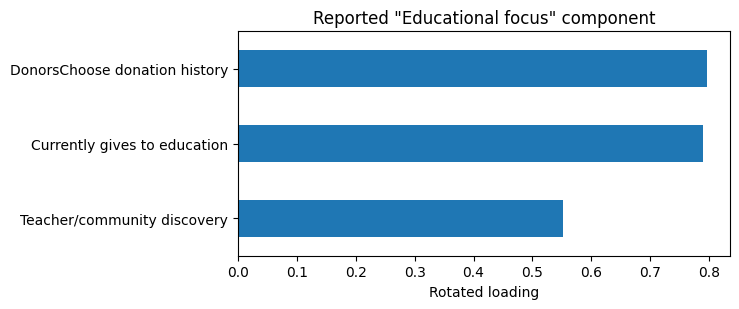

In [11]:
pca_loadings = pca_loadings_raw.iloc[:9, :4].copy()
pca_loadings.columns = ['variable', 'RC1', 'RC2', 'RC3']
pca_loadings = pca_loadings.set_index('variable').apply(pd.to_numeric)
reported_rc2 = pca_loadings.loc[
    [
        HISTORY_COL,
        option_col(Q_CURRENT_CAUSES, 'Educational-focused groups'),
        option_col(Q_DISCOVERY, 'Direct requests from community figures (e.g., teachers, organizers)'),
    ],
    'RC2',
].rename(index={
    HISTORY_COL: 'DonorsChoose donation history',
    option_col(Q_CURRENT_CAUSES, 'Educational-focused groups'): 'Currently gives to education',
    option_col(Q_DISCOVERY, 'Direct requests from community figures (e.g., teachers, organizers)'): 'Teacher/community discovery',
})
reported_rc2_table = reported_rc2.to_frame('Reported RC2 loading')
display(reported_rc2_table)
save_table(reported_rc2_table, 'B1_reported_education_factor_loadings.csv')

ax = reported_rc2.sort_values().plot(kind='barh', figsize=(7.5, 3.2), title='Reported "Educational focus" component')
ax.set_xlabel('Rotated loading')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## B2. Minimal reconstruction and three-run comparison

Reconstructed component most correlated with donor history: RC2; r=0.805


,Loading
history,0.810
education,0.789
teacher_requests,0.563
emotion,0.190
tax,0.110
recognition,-0.014
moral,-0.048
involvement,-0.073
social_ads,-0.083


,count,mean,std
donor_history,,,
Panel prospect,1120,-0.346,0.756
Past donor/list,125,3.099,0.838


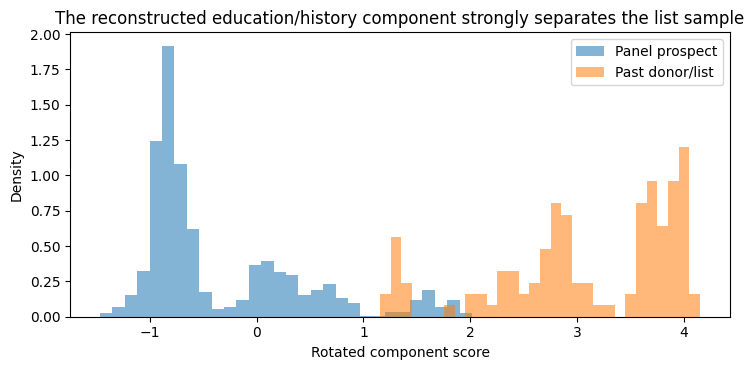

,education/donor cluster n,past donors in cluster,donor share of cluster,share of all past donors captured,prospect share in cluster,legacy Academic Advocates in cluster
run,,,,,,
A. Full nine-variable model,158,116,73.4%,92.8%,3.8%,157
B. Remove donor history,302,97,32.1%,77.6%,18.3%,142
"C. Fit prospects, then assign donors",337,98,29.1%,78.4%,21.3%,143


In [12]:
# The reconstructed component that is most correlated with donor history.
history_correlations = [np.corrcoef(run_a.scores[:, i], forensic['history'])[0, 1] for i in range(3)]
history_component = int(np.argmax(np.abs(history_correlations)))
reconstructed_factor = run_a.loadings.iloc[:, history_component].sort_values(ascending=False).to_frame('Loading')
print(f'Reconstructed component most correlated with donor history: RC{history_component + 1}; r={history_correlations[history_component]:.3f}')
display(reconstructed_factor)

score_by_history = pd.DataFrame({
    'component_score': run_a.scores[:, history_component],
    'donor_history': np.where(forensic['history'].eq(1), 'Past donor/list', 'Panel prospect'),
})
score_summary = score_by_history.groupby('donor_history')['component_score'].agg(['count', 'mean', 'std'])
display(score_summary)
save_table(score_summary, 'B2_component_score_by_history.csv')

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for group, values in score_by_history.groupby('donor_history')['component_score']:
    ax.hist(values, bins=30, alpha=0.55, density=True, label=group)
ax.set_title('The reconstructed education/history component strongly separates the list sample')
ax.set_xlabel('Rotated component score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


def cluster_donor_summary(labels: np.ndarray) -> tuple[pd.DataFrame, int]:
    donor = forensic['history'].to_numpy().astype(bool)
    table = pd.crosstab(pd.Series(labels, name='cluster'), pd.Series(donor, name='past_donor'))
    for val in [False, True]:
        if val not in table.columns:
            table[val] = 0
    table = table.reindex(columns=[False, True], fill_value=0).rename(columns={False: 'prospects', True: 'past_donors'})
    table['cluster_n'] = table.sum(axis=1)
    table['donor_share_of_cluster'] = table['past_donors'] / table['cluster_n']
    table['share_of_all_donors'] = table['past_donors'] / table['past_donors'].sum()
    table['share_of_all_prospects'] = table['prospects'] / table['prospects'].sum()
    donor_heaviest_cluster = int(table['past_donors'].idxmax())
    return table, donor_heaviest_cluster

summary_a, donor_cluster_a = cluster_donor_summary(run_a.labels)
summary_b, donor_cluster_b = cluster_donor_summary(run_b.labels)
summary_c, donor_cluster_c = cluster_donor_summary(run_c.labels)

legacy_academic = retained[LEGACY_CLUSTER_COL].eq('Academic Advocates').to_numpy()
retained_donor = forensic['history'].to_numpy().astype(bool)

comparison = pd.DataFrame([
    {
        'run': run_a.name,
        'education/donor cluster n': int(summary_a.loc[donor_cluster_a, 'cluster_n']),
        'past donors in cluster': int(summary_a.loc[donor_cluster_a, 'past_donors']),
        'donor share of cluster': summary_a.loc[donor_cluster_a, 'donor_share_of_cluster'],
        'share of all past donors captured': summary_a.loc[donor_cluster_a, 'share_of_all_donors'],
        'prospect share in cluster': summary_a.loc[donor_cluster_a, 'share_of_all_prospects'],
        'legacy Academic Advocates in cluster': int((legacy_academic & (run_a.labels == donor_cluster_a)).sum()),
    },
    {
        'run': run_b.name,
        'education/donor cluster n': int(summary_b.loc[donor_cluster_b, 'cluster_n']),
        'past donors in cluster': int(summary_b.loc[donor_cluster_b, 'past_donors']),
        'donor share of cluster': summary_b.loc[donor_cluster_b, 'donor_share_of_cluster'],
        'share of all past donors captured': summary_b.loc[donor_cluster_b, 'share_of_all_donors'],
        'prospect share in cluster': summary_b.loc[donor_cluster_b, 'share_of_all_prospects'],
        'legacy Academic Advocates in cluster': int((legacy_academic & (run_b.labels == donor_cluster_b)).sum()),
    },
    {
        'run': run_c.name,
        'education/donor cluster n': int(summary_c.loc[donor_cluster_c, 'cluster_n']),
        'past donors in cluster': int(summary_c.loc[donor_cluster_c, 'past_donors']),
        'donor share of cluster': summary_c.loc[donor_cluster_c, 'donor_share_of_cluster'],
        'share of all past donors captured': summary_c.loc[donor_cluster_c, 'share_of_all_donors'],
        'prospect share in cluster': summary_c.loc[donor_cluster_c, 'share_of_all_prospects'],
        'legacy Academic Advocates in cluster': int((legacy_academic & (run_c.labels == donor_cluster_c)).sum()),
    },
]).set_index('run')

display(comparison.style.format({
    'donor share of cluster': '{:.1%}',
    'share of all past donors captured': '{:.1%}',
    'prospect share in cluster': '{:.1%}',
}))
save_table(comparison, 'B3_three_run_comparison.csv')

# Expected diagnostic landmarks from the frozen data and deterministic implementation.
assert comparison.loc[run_a.name, 'past donors in cluster'] == 116
assert math.isclose(comparison.loc[run_a.name, 'donor share of cluster'], 0.734177, rel_tol=1e-4)
assert math.isclose(comparison.loc[run_a.name, 'share of all past donors captured'], 0.928, rel_tol=1e-3)
assert math.isclose(comparison.loc[run_c.name, 'share of all past donors captured'], 0.784, rel_tol=1e-3)

## B3. Evidence that some legacy Academic donors naturally belong elsewhere

In [13]:
legacy_academic_donors = retained[SOURCE_COL].eq('List') & retained[LEGACY_CLUSTER_COL].eq('Academic Advocates')
academic_donor_assignments = pd.Series(run_c.labels[legacy_academic_donors.to_numpy()], name='prospect_fitted_cluster')
migration = academic_donor_assignments.value_counts().sort_index().to_frame('legacy Academic past donors')
migration['share'] = migration['legacy Academic past donors'] / migration['legacy Academic past donors'].sum()
display(migration.style.format({'share': '{:.1%}'}))
save_table(migration, 'B4_legacy_academic_donor_migration.csv')

outside_primary = int((academic_donor_assignments != donor_cluster_c).sum())
assert outside_primary == 21

print(
    f'Of the {legacy_academic_donors.sum()} attention-pass prior donors originally labeled Academic Advocates, '
    f'{outside_primary} ({outside_primary / legacy_academic_donors.sum():.1%}) map outside the prospect-derived education-oriented cluster.'
)

,legacy Academic past donors,share
prospect_fitted_cluster,,
0,98,82.4%
1,9,7.6%
2,4,3.4%
3,8,6.7%


Of the 119 attention-pass prior donors originally labeled Academic Advocates, 21 (17.6%) map outside the prospect-derived education-oriented cluster.


> **Cut-and-dry conclusion**
>
> A natural education-oriented prospect profile exists, and current DonorsChoose donors strongly over-index on it. The legacy approach nevertheless overstated the equivalence between that profile and prior donors. Prospect-only fitting preserves the real education pattern while revealing a much larger prospect market and allowing some current donors to map to other natural personas.
>
> Current donors are not being discarded. Their role changes from defining the market personas to testing which prospect personas already fit DonorsChoose.